### The purpose of this project is to build a machine learning system that can automatically identify and categorize key entities in text, such as people, places, and organizations. This is a core task in Natural Language Processing (NLP) known as Named Entity Recognition (NER).

In [1]:
import nltk
nltk.download('conll2002')

[nltk_data] Downloading package conll2002 to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2002 is already up-to-date!


True

In [2]:
corpus = nltk.corpus.conll2002.iob_sents()

In [3]:
data = []
for cor in corpus:
    sent, _, tag = list(zip(*cor))
    data.append([sent, tag])

In [4]:
len(data)

35651

In [5]:
data[0]

[('Sao',
  'Paulo',
  '(',
  'Brasil',
  ')',
  ',',
  '23',
  'may',
  '(',
  'EFECOM',
  ')',
  '.'),
 ('B-LOC', 'I-LOC', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'O')]

## Numerization


In [6]:
flatten = lambda l: [item for sublist in l for item in sublist]

sents, tags = list(zip(*data))
vocab  = list(set(flatten(sents)))
tagset = list(set(flatten(tags)))

In [7]:
tagset

['I-PER', 'I-ORG', 'B-MISC', 'B-ORG', 'I-LOC', 'O', 'B-LOC', 'I-MISC', 'B-PER']

In [8]:
word2index = {'<UNK>': 0, '<DUMMY>': 1}
for v in vocab:
    if word2index.get(v) is None:
        word2index[v] = len(word2index)
index2word = {v:k for k, v in word2index.items()}

tag2index = {}
for v in tagset:
    if tag2index.get(v) is None:
        tag2index[v] = len(tag2index)
index2tag = {v:k for k, v in tag2index.items()}

## Preparing the Window

In [9]:
window_size = 2
windows = []

In [10]:
for sample in data:
    dummy= ["<DUMMY>"]*window_size
    text = sample[0]
    padded_text= dummy+list(sample[0]) + dummy
    window = list(nltk.ngrams(padded_text, window_size*2+1))
    windows.extend([[list(window[i]), sample[1][i]] for i in range(len(sample[0]))])
    

In [11]:
windows = windows[:10000]

In [12]:
import random
random.shuffle(windows)

train_data = windows[:int(len(windows) * 0.9)]
test_data  = windows[int(len(windows) * 0.9):]

## Prepare batch

In [13]:
import torch
def prepare_sequence(seq, word2index):
    idxs = list(map(lambda w: word2index[w] if word2index.get(w) is not None else word2index["<UNK>"], seq))
    return torch.LongTensor(idxs)

def prepare_tag(tag,tag2index):
    return torch.LongTensor([tag2index[tag]])

In [14]:
def getBatch(batch_size, train_data):
    random.shuffle(train_data)
    sindex = 0
    eindex = batch_size
    while eindex < len(train_data):
        batch = train_data[sindex:eindex]
        temp  = eindex
        eindex = eindex + batch_size
        sindex = temp
        yield batch
        
    if eindex >= len(train_data):
        batch = train_data[sindex:]
        yield batch

## Defining the model

In [15]:
import torch.nn as nn

class NER(nn.Module):
    
    def __init__(self, vocab_size, embed_size, hidden_size, window_size, out_size):
        super(NER, self).__init__()
        
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.layer1 = nn.Linear(embed_size * (window_size*2+1), hidden_size)
        self.layer2 = nn.Linear(hidden_size, out_size) #predict the probability of each tag
        self.relu   = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, inputs):
        embeds = self.embed(inputs) #(batch_size, 5, emb_size)
        embeds = embeds.view(-1, embeds.size(1) * embeds.size(2)) #(batch_size, 5 * emb_size)
        h0 = self.dropout(self.relu(self.layer1(embeds)))
        out = self.layer2(h0)
        return out

## Training

In [16]:
batch_size = 2
embed_size = 4
hidden_size = 8
num_epochs  = 5

In [17]:
import torch.optim as optim

model = NER(len(word2index), embed_size, hidden_size, window_size, len(tag2index))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [18]:
import numpy as np

model.train() #turn on dropout

for epoch in range(num_epochs):
    losses = []
    for i, batch in enumerate(getBatch(batch_size, train_data)):
        
        x,y = list(zip(*batch))
        
        inputs  = torch.cat([prepare_sequence(sent, word2index).view(1, -1) for sent in x])
        targets = torch.cat([prepare_tag(tag, tag2index) for tag in y])
        
        preds = model(inputs)
        loss  = criterion(preds, targets)
        losses.append(loss.item())
        
        model.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch: {epoch + 1} | Batch: {i: 5.0f} | Loss: {np.mean(losses):.6f}")
        

Epoch: 1 | Batch:  4499 | Loss: 0.792736
Epoch: 2 | Batch:  4499 | Loss: 0.667930
Epoch: 3 | Batch:  4499 | Loss: 0.638730
Epoch: 4 | Batch:  4499 | Loss: 0.609341
Epoch: 5 | Batch:  4499 | Loss: 0.581562


## Test

In [19]:
for_f1_score = []

In [20]:
accuracy = 0

model.eval() #this will turn off dropout

for test in test_data:
    x, y = test[0], test[1]
    input = prepare_sequence(x, word2index).view(1, -1)
    preds = model(input) #(batch_size, probability over all tagset)
    
    i = preds.max(1)[1]
    pred = index2tag[i.item()]
    for_f1_score.append([pred, y])
    if pred == y:
        accuracy += 1
    
print(accuracy / len(test_data) * 100)
    

84.3


This high score is because most of labels are 'O' tag. So we need to measure f1 score.

In [21]:
yhat, y = list(zip(*for_f1_score))

In [22]:
set(yhat)

{'O'}

In [23]:
from sklearn import metrics

print(metrics.classification_report(yhat, y))

              precision    recall  f1-score   support

       B-LOC       0.00      0.00      0.00         0
      B-MISC       0.00      0.00      0.00         0
       B-ORG       0.00      0.00      0.00         0
       B-PER       0.00      0.00      0.00         0
       I-LOC       0.00      0.00      0.00         0
      I-MISC       0.00      0.00      0.00         0
       I-ORG       0.00      0.00      0.00         0
       I-PER       0.00      0.00      0.00         0
           O       1.00      0.84      0.91      1000

    accuracy                           0.84      1000
   macro avg       0.11      0.09      0.10      1000
weighted avg       1.00      0.84      0.91      1000



C:\Users\Dell\anaconda3\envs\tf-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\envs\tf-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\envs\tf-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


A window based model typically considers only a fixed-size neighborhood around a word (e.g., 2 words before and after). It is highly effective for identifying entities that depend on immediate neighbors but may fail to resolve ambiguities that require broader context.

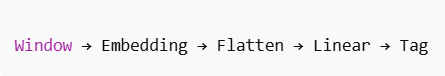

But a BiLSTM captures the full sentence context by reading text in both directions (forward and backward). It is not limited by a fixed window size, making it better for capturing long-distance dependencies between words, which is crucial for identifying complex entities

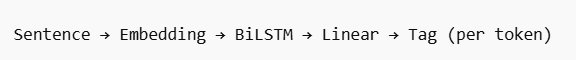

## Implementing BiLSTM

In [24]:
#prepare sentence to index fuction

def prepare_word_sequence(seq, word2index):
    indices = []
    for w in seq:
        if w in word2index:
            indices.append(word2index[w])
        else:
            indices.append(word2index["<UNK>"])
    return torch.tensor(indices, dtype=torch.long)

def prepare_tag_sequence(seq, tag2index):
    return torch.tensor(
        [tag2index[w] for w in seq],
        dtype=torch.long
    )


In [25]:
class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim, hidden_dim):
        super(BiLSTM_NER, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(

        embedding_dim,
        hidden_dim,
        batch_first =True,
        bidirectional =True
        )

        self.fc= nn.Linear(hidden_dim*2,tagset_size)


    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        embeds = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        
        # lstm_out contains the hidden states for all time steps
        # shape: (batch_size, seq_len, hidden_dim * 2)
        lstm_out, _ = self.lstm(embeds)
        
        # We apply the linear layer to every time step in the sequence
        logits = self.fc(lstm_out)  # (batch_size, seq_len, tagset_size)
        
        return logits

In [26]:
embedding_dim = 100
hidden_dim = 120

model = BiLSTM_NER(
    vocab_size = len(word2index),
    tagset_size = len(tag2index),
    embedding_dim= embedding_dim,
    hidden_dim=hidden_dim
)

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):

    model.train()
    total_loss = 0

    for sentence, tags in data:   # ← FIXED HERE

        model.zero_grad()

        sentence_in = prepare_word_sequence(sentence, word2index).unsqueeze(0)
        targets = prepare_tag_sequence(tags, tag2index).unsqueeze(0)

        outputs = model(sentence_in)

        outputs = outputs.reshape(-1, outputs.shape[-1])
        targets = targets.reshape(-1)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [1]:
#since BiLSTMis taking too long to train. Will look for alternatives